# Predicting F1 Tyre Degradation to Optimize Pit Stop Strategy
**Kevin Zong (115265318) & Michael Obajemu (114202291)**

Midterm checkpoint. So far we have:
- A pipeline that pulls and caches 2024 & 2025 F1 season data from FastF1
- Data cleaning process to remove the non-regular data such as safety car laps, in/out laps, and anomalies
- Added new features: fuel-corrected lap time, lap time delta, tyre-life ratio
- Exploratory visualizations: distributions, degradation curves by compound, correlation matrix

In [1]:
# !pip install fastf1

import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import gaussian_kde
import warnings
import logging

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

fastf1.Cache.enable_cache('fastf1_cache')

print('Dependencies loaded successfully.')

Dependencies loaded successfully.


## 1. Data Collection

First, we'll pull race data from the 2024 season (training set) and 2025 season (validation set). Each season has 24 races and approximately 50,000 laps (rows) total. Each row contains lap time, tyre compound, tyre life, stint number, pit events, and weather conditions. Both seasons share the same set of circuits.

**Note:** The first run downloads and caches data locally so subsequent runs are much faster.

In [2]:
ROUNDS = [
    (2024, 1,  'Bahrain'),
    (2024, 2,  'Saudi Arabia'),
    (2024, 3,  'Australia'),
    (2024, 4,  'Japan'),
    (2024, 5,  'China'),
    (2024, 6,  'Miami'),
    (2024, 7,  'Emilia Romagna'),
    (2024, 8,  'Monaco'),
    (2024, 9,  'Canada'),
    (2024, 10, 'Spain'),
    (2024, 11, 'Austria'),
    (2024, 12, 'Great Britain'),
    (2024, 13, 'Hungary'),
    (2024, 14, 'Belgium'),
    (2024, 15, 'Netherlands'),
    (2024, 16, 'Italy'),
    (2024, 17, 'Azerbaijan'),
    (2024, 18, 'Singapore'),
    (2024, 19, 'United States'),
    (2024, 20, 'Mexico'),
    (2024, 21, 'Brazil'),
    (2024, 22, 'Las Vegas'),
    (2024, 23, 'Qatar'),
    (2024, 24, 'Abu Dhabi'),
    (2025, 1,  'Australia'),
    (2025, 2,  'China'),
    (2025, 3,  'Japan'),
    (2025, 4,  'Bahrain'),
    (2025, 5,  'Saudi Arabia'),
    (2025, 6,  'Miami'),
    (2025, 7,  'Emilia Romagna'),
    (2025, 8,  'Monaco'),
    (2025, 9,  'Spain'),
    (2025, 10, 'Canada'),
    (2025, 11, 'Austria'),
    (2025, 12, 'Great Britain'),
    (2025, 13, 'Belgium'),
    (2025, 14, 'Hungary'),
    (2025, 15, 'Netherlands'),
    (2025, 16, 'Italy'),
    (2025, 17, 'Azerbaijan'),
    (2025, 18, 'Singapore'),
    (2025, 19, 'United States'),
    (2025, 20, 'Mexico'),
    (2025, 21, 'Brazil'),
    (2025, 22, 'Las Vegas'),
    (2025, 23, 'Qatar'),
    (2025, 24, 'Abu Dhabi'),
]

all_laps = []
logging.getLogger('fastf1').setLevel(logging.ERROR)

for year, rnd, name in ROUNDS:
    try:
        session = fastf1.get_session(year, rnd, 'R')
        # we only need laps and weather, so we'll skip telemetry and messages to speed up loading
        session.load(telemetry=False, weather=True, messages=False)
        laps = session.laps.copy()
        laps['Race']  = name
        laps['Year']  = year
        laps['Round'] = rnd

        if session.weather_data is not None and not session.weather_data.empty:
            laps['AirTemp']   = session.weather_data['AirTemp'].mean()
            laps['TrackTemp'] = session.weather_data['TrackTemp'].mean()
        else:
            laps['AirTemp']   = np.nan
            laps['TrackTemp'] = np.nan

        all_laps.append(laps)
        print(f'  Loaded {name} {year}: {len(laps)} laps')
    except Exception as e:
        print(f'  Failed to load {name} {year}: {e}')

raw_df = pd.concat(all_laps, ignore_index=True)
print(f'\nRaw dataset: {len(raw_df)} laps across {raw_df["Race"].nunique()} races')

  Loaded Bahrain 2024: 1129 laps
  Loaded Saudi Arabia 2024: 901 laps
  Loaded Australia 2024: 998 laps
  Loaded Japan 2024: 907 laps
  Loaded China 2024: 1032 laps
  Loaded Miami 2024: 1111 laps
  Loaded Emilia Romagna 2024: 1238 laps
  Loaded Monaco 2024: 1237 laps
  Loaded Canada 2024: 1272 laps
  Loaded Spain 2024: 1310 laps
  Loaded Austria 2024: 1405 laps
  Loaded Great Britain 2024: 961 laps
  Loaded Hungary 2024: 1355 laps
  Loaded Belgium 2024: 841 laps
  Loaded Netherlands 2024: 1426 laps
  Loaded Italy 2024: 1008 laps
  Loaded Azerbaijan 2024: 973 laps
  Loaded Singapore 2024: 1177 laps
  Loaded United States 2024: 1059 laps
  Loaded Mexico 2024: 1215 laps
  Loaded Brazil 2024: 1135 laps
  Loaded Las Vegas 2024: 938 laps
  Loaded Qatar 2024: 943 laps
  Loaded Abu Dhabi 2024: 1035 laps
  Loaded Australia 2025: 927 laps
  Loaded China 2025: 1065 laps
  Loaded Japan 2025: 1059 laps
  Loaded Bahrain 2025: 1128 laps
  Loaded Saudi Arabia 2025: 898 laps
  Loaded Miami 2025: 1005 l

## 2. Data Cleaning

We chose to remove laps that we feel don't reflect genuine tyre degradation:
- **In-laps / out-laps** - speed limits are enforced distortig lap times
- **Safety car / Virtual Safety Car (VSC) / red flag laps** - speed is also capped in these
- **Wet/intermediate compounds** — out of scope for this model
- **Statistical outliers** — laps with times > 3 std deviations from per-race mean. These extreme times are usually caused by factors like spins or collisions rather than tyre degradation
- **Missing key fields** - lap time, tyre life, compound, driver

In [5]:
df = raw_df.copy()
print(f'Laps before cleaning: {len(df)}')

# Only keep laps where the driver didn't enter or exit the pit lane
df = df[df['PitInTime'].isna() & df['PitOutTime'].isna()]

# Remove laps with status codes 4 (safety car), 5 (VSC), 6 (red flag)
if 'TrackStatus' in df.columns:
    df = df[~df['TrackStatus'].astype(str).str.contains('4|5|6', na=False)]

# Filter out wet/intermediate compounds
df = df[df['Compound'].isin(['SOFT', 'MEDIUM', 'HARD'])]

# Drop rows missing key fields
df = df.dropna(subset=['LapTime', 'TyreLife', 'Compound', 'Driver'])

# Convert LapTime to seconds, drop erroneous laps
df['LapTimeSec'] = df['LapTime'].dt.total_seconds()
df = df[df['LapTimeSec'] > 60]

# Step 6: Remove per-race outliers (> 3 std from race mean)
race_stats = df.groupby('Race')['LapTimeSec'].agg(['mean', 'std']).reset_index() # calculate mean and std of lap times for each race
df = df.merge(race_stats, on='Race') # merge back to original df so each lap now has its race's mean and std
df = df[np.abs(df['LapTimeSec'] - df['mean']) <= 3 * df['std']] # keep only laps within 3 std of that race's mean
df = df.drop(columns=['mean', 'std']) # remove the temporary mean and std columns

print(f'Laps after cleaning:  {len(df)}')

Laps before cleaning: 53298
Laps after cleaning:  43445


## 3. Feature Engineering


- `LapTimeDelta`: Lap time minus per-driver per-stint median — captures degradation relative to each driver's fresh pace
- `FuelCorrectedLap`: What a car's lap time would be if it were running on a standardized fuel load (usually empty or full) (adjusts ~0.03s per lap)
- `TyreLifeRatio`: Tyre life normalized 0–1 within each stint
- `CompoundEncoded`: Ordinal: SOFT=0, MEDIUM=1, HARD=2
- `StintLength`: Total laps in that driver's stint

In [7]:
# Lap time delta relative to each driver's per-stint median
stint_medians = df.groupby(['Race', 'Driver', 'Stint'])['LapTimeSec'].transform('median')
df['LapTimeDelta'] = df['LapTimeSec'] - stint_medians

# Fuel correction
df['FuelCorrectedLap'] = df['LapTimeSec'] - (0.03 * df['LapNumber'])

# Tyre life ratio within each stint
stint_max_life = df.groupby(['Race', 'Driver', 'Stint'])['TyreLife'].transform('max')
df['TyreLifeRatio'] = df['TyreLife'] / stint_max_life.replace(0, np.nan)

# Compound encoding
df['CompoundEncoded'] = df['Compound'].map({'SOFT': 0, 'MEDIUM': 1, 'HARD': 2})

# Stint length
df['StintLength'] = df.groupby(['Race', 'Driver', 'Stint'])['LapTimeSec'].transform('count')

print(f'Dataset shape after adding features: {df.shape}')
df[['Race', 'Year', 'Driver', 'Compound', 'TyreLife', 'LapTimeSec',
    'LapTimeDelta', 'FuelCorrectedLap', 'TyreLifeRatio', 'CompoundEncoded',
    'StintLength']].head(10)

Dataset shape after adding features: (43445, 42)


,Race,Year,Driver,Compound,TyreLife,LapTimeSec,LapTimeDelta,FuelCorrectedLap,TyreLifeRatio,CompoundEncoded,StintLength
0,Bahrain,2024,VER,SOFT,4.0,97.284,0.154,97.254,0.210526,0,24
1,Bahrain,2024,VER,SOFT,5.0,96.296,-0.834,96.236,0.263158,0,24
2,Bahrain,2024,VER,SOFT,6.0,96.753,-0.377,96.663,0.315789,0,24
3,Bahrain,2024,VER,SOFT,7.0,96.647,-0.483,96.527,0.368421,0,24
4,Bahrain,2024,VER,SOFT,8.0,97.173,0.043,97.023,0.421053,0,24
5,Bahrain,2024,VER,SOFT,9.0,97.092,-0.038,96.912,0.473684,0,24
6,Bahrain,2024,VER,SOFT,10.0,97.038,-0.092,96.828,0.526316,0,24
7,Bahrain,2024,VER,SOFT,11.0,97.024,-0.106,96.784,0.578947,0,24
8,Bahrain,2024,VER,SOFT,12.0,97.229,0.099,96.959,0.631579,0,24
9,Bahrain,2024,VER,SOFT,13.0,96.960,-0.170,96.660,0.684211,0,24


## 4. Exploratory Visualizations

### 4.1 Tyre Life Distribution by Compound

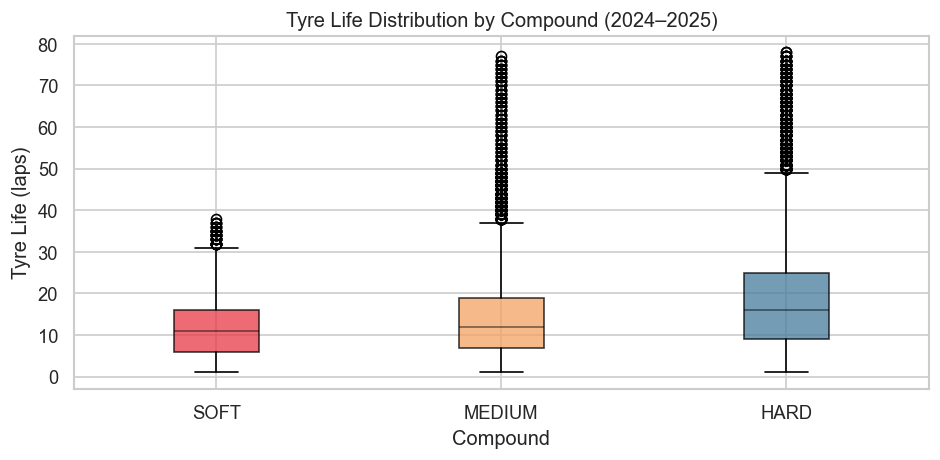

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))

compounds = ['SOFT', 'MEDIUM', 'HARD']
colors = ['#e63946', '#f4a261', '#457b9d']
data = [df[df['Compound'] == c]['TyreLife'].dropna() for c in compounds]

bp = ax.boxplot(data, patch_artist=True, medianprops=dict(color='black', alpha=0.5))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.set_xticklabels(compounds)
ax.set_xlabel('Compound')
ax.set_ylabel('Tyre Life (laps)')
ax.set_title('Tyre Life Distribution by Compound (2024–2025)')
plt.tight_layout()
plt.savefig('plot_02_tyre_life_dist.png', bbox_inches='tight')
plt.show()

**Interpretation**

SOFT tyres have the shortest median stint (~10 laps) and tightest IQR, reflecting their limited durability. HARD tyres show the highest median (~15 laps) and widest IQR, consistent with flexible long-stint usage. MEDIUM sits between the two in median but has extensive outliers reaching 70+ laps — likely anomalous stints (e.g., drivers staying out under unusual race circumstances) that should be investigated during modeling. Both MEDIUM and HARD show heavy upper-tail outliers, suggesting stint length filtering (e.g., capping at 40–50 laps) may be needed to prevent extreme stints from skewing the degradation model.

## 5. Challenges

- **Weather data gaps**: Not all sessions return complete weather data through FastF1. Missing `AirTemp` / `TrackTemp` values will be imputed from circuit historical averages or dropped for the baseline model.
- **Safety car edge cases**: `TrackStatus` is the most reliable flag but some partially neutralized laps still slip through. A secondary z-score filter per lap number may improve this.
- **Stint boundary noise**: The first 1–2 laps of each stint sometimes show anomalously fast times (fresh tyres + open track). We may exclude lap 1 per stint from the degradation target.
- **Per-stint median baseline**: Using stint median as the baseline for `LapTimeDelta` partially absorbs the degradation signal, contributing to the weak linear correlations observed. Alternative baselines (e.g., first-lap or rolling window) will be explored during modeling.
- **Extreme stint outliers**: MEDIUM and HARD compounds show stints reaching 70–80 laps, which likely reflect unusual race circumstances. These will need to be capped or filtered before training.

## 6. Next Steps

**Weeks 5–6 — Modeling (Kevin)**
1. Baseline Linear Regression: predict `LapTimeDelta` from `TyreLife`, `CompoundEncoded`, `TrackTemp`, `StintLength`, and circuit one-hot encoding
1. Time-based cross-validation: train on 2024 season, validate on 2025 season
1. Random Forest and XGBoost: compare RMSE and feature importances against baseline
1. Target: RMSE < 0.3s per lap on held-out 2025 races

**Weeks 7–8 — Pit-Stop Optimizer (Michael)**
1. Build race-simulation module: given predicted degradation curves, identify compound sequence and stint lengths minimizing total race time
1. Back-test against actual 2025 race outcomes — target: strategy within 2 laps of actual optimal on ≥60% of test races